# Concrete Crack Segmentation & Severity Estimation (TensorFlow / Keras)

**Deep Learning Course Project**

This notebook builds a two-stage system for automated concrete crack inspection using
**TensorFlow/Keras**:

1. A **U-Net segmentation model** locates cracks in an image at the pixel level.
2. A **post-processing pipeline** measures the crack geometry (width, coverage) and buckets
   each crack into a severity tier, turning a raw mask into an inspection-relevant output.

To satisfy the from-scratch vs. transfer-learning comparison, we build **two U-Nets with the
same decoder**, differing only in the encoder:

- **Model A**: a plain convolutional encoder, randomly initialized (from scratch).
- **Model B**: a **MobileNetV2** encoder pretrained on ImageNet (transfer learning).

Everything else (data, decoder architecture, loss function, training settings) is held
identical between the two, so any difference in results is attributable to the encoder's
starting weights.

---

## Table of Contents

1. [Setup & Environment](#1-setup--environment)
2. [Imports & Configuration](#2-imports--configuration)
3. [Dataset: Download & Mask Preparation](#3-dataset-download--mask-preparation)
4. [Data Visualization](#4-data-visualization)
5. [tf.data Input Pipeline](#5-tfdata-input-pipeline)
6. [Model A — U-Net From Scratch](#6-model-a--u-net-from-scratch)
7. [Model B — U-Net with MobileNetV2 (Transfer Learning)](#7-model-b--u-net-with-mobilenetv2-transfer-learning)
8. [Training Comparison](#8-training-comparison)
9. [Model Evaluation](#9-model-evaluation)
10. [Severity Quantification Pipeline](#10-severity-quantification-pipeline)
11. [End-to-End Demo](#11-end-to-end-demo)
12. [Save & Export](#12-save--export)
13. [Summary & Next Steps](#13-summary--next-steps)

> **Note:** Run this in Google Colab with a GPU runtime (Runtime -> Change runtime type -> GPU).
> We use the `ultralytics` package for exactly one thing: downloading the Crack-Seg dataset.
> All model building and training in this notebook is pure TensorFlow/Keras, no PyTorch.


## 1. Setup & Environment

TensorFlow comes preinstalled in Colab. We additionally install:
- `ultralytics`, used only to download the Crack-Seg dataset (its labels come in YOLO
  polygon format, which we rasterize into masks ourselves in Section 3).
- `scikit-image`, used later for skeletonizing crack masks (severity measurement, Section 10).

In [1]:
!pip install ultralytics -q
!pip install scikit-image -q

print("Setup complete.")


Setup complete.


In [2]:
# Sanity check: confirm TensorFlow sees a GPU.
# If this prints an empty list, go to Runtime -> Change runtime type -> GPU and re-run.
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs detected:", gpus if gpus else "None (training will be slow on CPU)")


TensorFlow version: 2.20.0
GPUs detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Imports & Configuration

All the "knobs" for this notebook live in one place (`CONFIG`) so you can tweak image size,
batch size, and epoch count in a single spot without hunting through the rest of the
notebook.

In [3]:
import os
import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import ndimage
from skimage.morphology import skeletonize

import tensorflow as tf
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from ultralytics.data.utils import check_det_dataset

# Reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.


In [4]:
# ---------------------------------------------------------------------------
# CONFIG: adjust these to fit your Colab GPU / time budget
# ---------------------------------------------------------------------------
CONFIG = {
    "data_yaml": "crack-seg.yaml",   # Ultralytics' built-in Crack Segmentation dataset config
    "img_size": 224,                 # MobileNetV2's native input size; keep this unless you
                                      # also change the encoder skip-connection layers below.
    "batch_size": 16,
    "epochs": 20,
    "mask_dir_train": "masks/train", # where rasterized ground-truth masks are cached
    "mask_dir_val": "masks/val",
}

print(CONFIG)


{'data_yaml': 'crack-seg.yaml', 'img_size': 224, 'batch_size': 16, 'epochs': 20, 'mask_dir_train': 'masks/train', 'mask_dir_val': 'masks/val'}


## 3. Dataset: Download & Mask Preparation

We reuse the same **Crack Segmentation Dataset** (4,029 images) as before. Its labels are
stored in YOLO polygon format (normalized `x y` coordinate pairs per crack region), which
is what Ultralytics models expect. Since U-Net expects a plain binary mask image instead,
we rasterize each label file into a black-and-white PNG mask once, then reuse those cached
masks for training.

In [5]:
# One-time dataset download (skips re-downloading if already present)
dataset_info = check_det_dataset(CONFIG["data_yaml"])

DATASET_ROOT = Path(dataset_info["path"])
TRAIN_IMG_DIR = DATASET_ROOT / dataset_info["train"]
VAL_IMG_DIR = DATASET_ROOT / dataset_info.get("val", dataset_info.get("test", ""))

print("Dataset root:", DATASET_ROOT)
print("Train images dir:", TRAIN_IMG_DIR)
print("Val images dir:", VAL_IMG_DIR)



WARNING ⚠️ Dataset 'crack-seg.yaml' images not found, missing path '/content/datasets/crack-seg/images/val'
Unzipping /content/datasets/crack-seg.zip to /content/datasets/crack-seg...: 100% ━━━━━━━━━━━━ 8067/8067 3.2Kfiles/s 2.5s
Dataset download success ✅ (3.9s), saved to /content/datasets

Dataset root: /content/datasets/crack-seg
Train images dir: /content/datasets/crack-seg/images/train
Val images dir: /content/datasets/crack-seg/images/val


In [6]:
def list_images(img_dir):
    img_dir = Path(img_dir)
    files = []
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        files.extend(img_dir.glob(ext))
    return sorted(files)


def yolo_seg_label_path(image_path):
    """YOLO datasets mirror the images/ folder with a labels/ folder of the same structure."""
    parts = list(Path(image_path).parts)
    parts[parts.index("images")] = "labels"
    return Path(*parts).with_suffix(".txt")


def load_polygons(label_path, img_w, img_h):
    """
    Parse a YOLO-segmentation label file into a list of pixel-coordinate polygons.
    Each line: class_id x1 y1 x2 y2 x3 y3 ... (all coordinates normalized 0-1).
    """
    polygons = []
    if not Path(label_path).exists():
        return polygons
    with open(label_path, "r") as f:
        for line in f.readlines():
            values = line.strip().split()
            if len(values) < 7:
                continue
            coords = np.array(values[1:], dtype=float).reshape(-1, 2)
            coords[:, 0] *= img_w
            coords[:, 1] *= img_h
            polygons.append(coords.astype(np.int32))
    return polygons


train_images = list_images(TRAIN_IMG_DIR)
val_images = list_images(VAL_IMG_DIR)
print(f"Training images: {len(train_images)}")
print(f"Validation images: {len(val_images)}")


Training images: 3717
Validation images: 200


In [7]:
def rasterize_masks(image_paths, output_dir):
    """
    Convert each image's YOLO polygon label into a single-channel PNG mask
    (255 = crack, 0 = background), cached to disk so we only do this once.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    for img_path in image_paths:
        out_path = output_dir / f"{img_path.stem}.png"
        if out_path.exists():
            continue  # already rasterized, skip

        img = cv2.imread(str(img_path))
        h, w = img.shape[:2]
        polygons = load_polygons(yolo_seg_label_path(img_path), w, h)

        mask = np.zeros((h, w), dtype=np.uint8)
        for poly in polygons:
            cv2.fillPoly(mask, [poly], color=255)

        cv2.imwrite(str(out_path), mask)

    return output_dir


TRAIN_MASK_DIR = rasterize_masks(train_images, CONFIG["mask_dir_train"])
VAL_MASK_DIR = rasterize_masks(val_images, CONFIG["mask_dir_val"])

print(f"Rasterized {len(list(TRAIN_MASK_DIR.glob('*.png')))} training masks -> {TRAIN_MASK_DIR}")
print(f"Rasterized {len(list(VAL_MASK_DIR.glob('*.png')))} validation masks -> {VAL_MASK_DIR}")


Rasterized 3717 training masks -> masks/train
Rasterized 200 validation masks -> masks/val


## 4. Data Visualization

Sanity-check the rasterized masks against their source images before spending any GPU time
training on them.

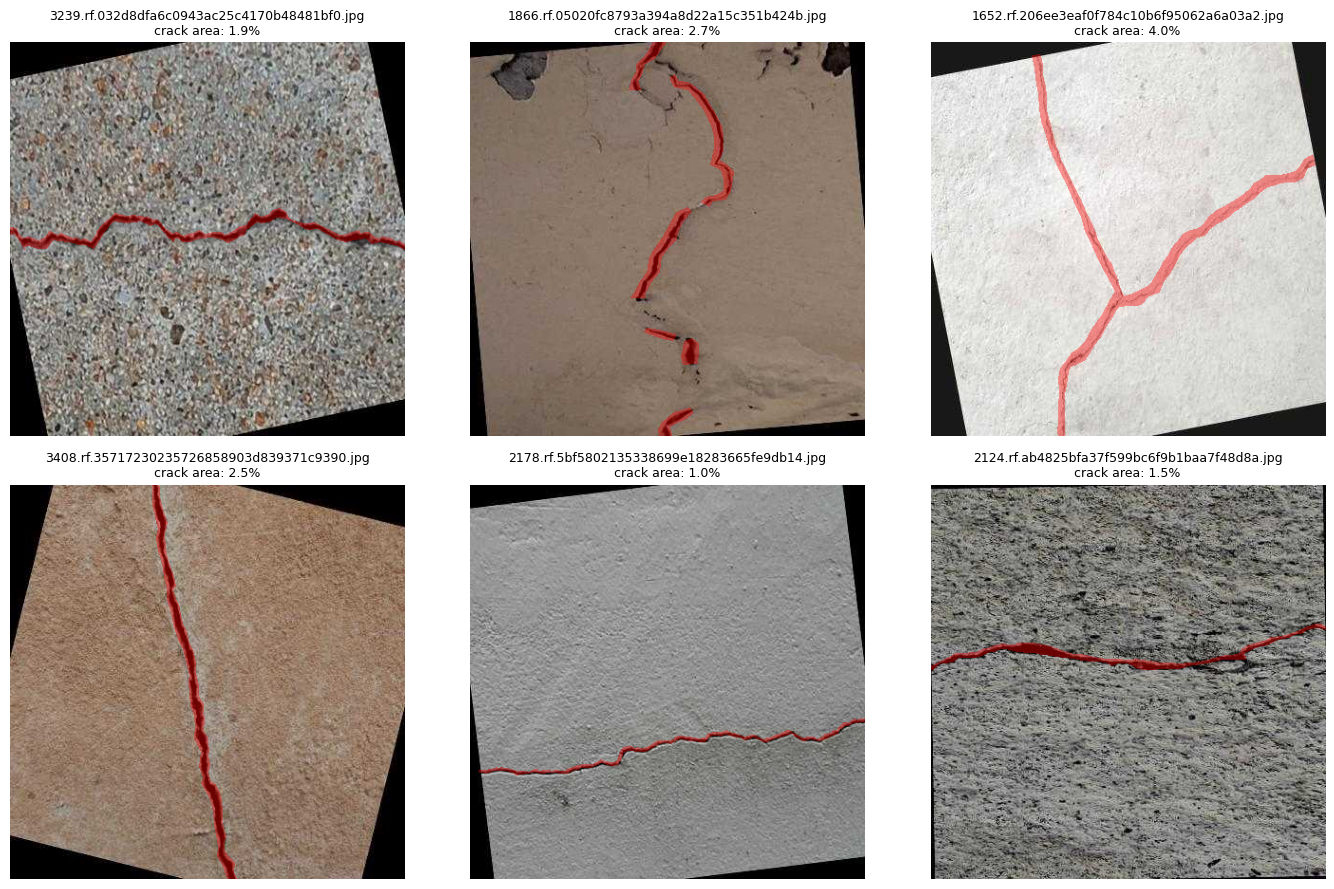

In [8]:
def show_image_and_mask(img_path, mask_dir, ax):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    mask_path = Path(mask_dir) / f"{img_path.stem}.png"
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    overlay = img.copy()
    overlay[mask > 127] = [255, 0, 0]
    blended = cv2.addWeighted(img, 0.6, overlay, 0.4, 0)

    ax.imshow(blended)
    crack_pct = (mask > 127).mean() * 100
    ax.set_title(f"{img_path.name}\ncrack area: {crack_pct:.1f}%", fontsize=9)
    ax.axis("off")


sample_paths = random.sample(train_images, min(6, len(train_images)))
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, path in zip(axes.flatten(), sample_paths):
    show_image_and_mask(path, TRAIN_MASK_DIR, ax)
plt.tight_layout()
plt.show()


## 5. tf.data Input Pipeline

Build an efficient `tf.data.Dataset` that reads an image + its matching mask, resizes both
to `CONFIG["img_size"]`, and normalizes pixel values. Images are resized with bilinear
interpolation (smooth); masks are resized with **nearest-neighbor** interpolation so we
never introduce fractional/blurred mask values that aren't really 0 or 1.

### Augmentation (training set only)
Crack-Seg has ~4,000 images, not huge for a segmentation task, so we augment the
**training** split to reduce overfitting: random horizontal/vertical flips (cracks have no
canonical orientation), small random rotations, and random brightness/contrast jitter
(concrete photos are taken under very different lighting). Every augmentation is applied
identically to the image and its mask together, a flip that isn't mirrored on the mask
would silently misalign the labels. The validation set is left untouched, since we want to
evaluate on realistic, unmodified data.

In [9]:
def load_image_mask(img_path, mask_path, img_size):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [img_size, img_size], method="bilinear")
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [img_size, img_size], method="nearest")
    mask = tf.cast(mask, tf.float32) / 255.0

    return img, mask


def augment_image_mask(img, mask):
    """
    Apply the same random flips/rotation to both the image and its mask, and
    apply photometric jitter (brightness/contrast) to the image only -- the mask
    has no "brightness" to jitter, only geometry needs to stay in sync.
    """
    # --- Geometric augmentation: must be identical on image and mask ---
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)

    # Random 0/90/180/270-degree rotation (safe, no interpolation artifacts on the mask)
    k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
    img = tf.image.rot90(img, k=k)
    mask = tf.image.rot90(mask, k=k)

    # --- Photometric augmentation: image only ---
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)  # keep pixel values valid after jitter

    return img, mask


def build_dataset(image_paths, mask_dir, img_size, batch_size, shuffle, augment=False):
    img_path_strs = [str(p) for p in image_paths]
    mask_path_strs = [str(Path(mask_dir) / f"{p.stem}.png") for p in image_paths]

    ds = tf.data.Dataset.from_tensor_slices((img_path_strs, mask_path_strs))
    ds = ds.map(lambda i, m: load_image_mask(i, m, img_size), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=256, seed=42)
    if augment:
        ds = ds.map(augment_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Augmentation is ON for training, OFF for validation -- we want validation
# metrics to reflect real, unmodified images.
train_ds = build_dataset(train_images, TRAIN_MASK_DIR, CONFIG["img_size"], CONFIG["batch_size"],
                          shuffle=True, augment=True)
val_ds = build_dataset(val_images, VAL_MASK_DIR, CONFIG["img_size"], CONFIG["batch_size"],
                        shuffle=False, augment=False)

# Quick shape check
for imgs, masks in train_ds.take(1):
    print("Image batch shape:", imgs.shape)
    print("Mask batch shape:", masks.shape)


Image batch shape: (16, 224, 224, 3)
Mask batch shape: (16, 224, 224, 1)


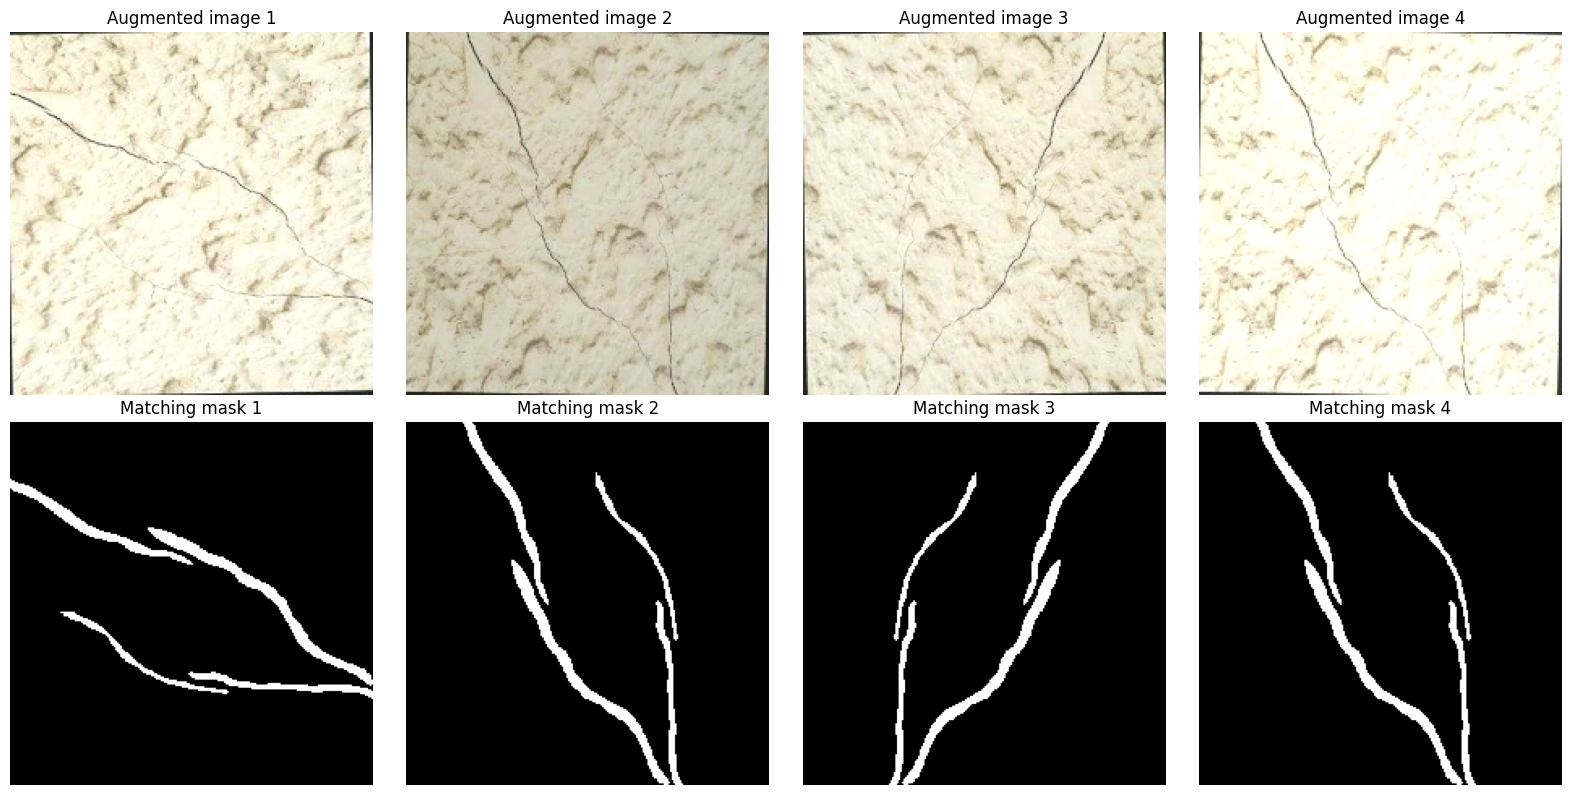

In [10]:
# Visual sanity check: same image run through the augmentation pipeline several times,
# so we can eyeball that flips/rotations/jitter look reasonable and masks stay aligned.
sample_img_path = str(train_images[0])
sample_mask_path = str(Path(TRAIN_MASK_DIR) / f"{train_images[0].stem}.png")
base_img, base_mask = load_image_mask(sample_img_path, sample_mask_path, CONFIG["img_size"])

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    aug_img, aug_mask = augment_image_mask(base_img, base_mask)
    axes[0, i].imshow(aug_img.numpy())
    axes[0, i].set_title(f"Augmented image {i+1}")
    axes[0, i].axis("off")
    axes[1, i].imshow(aug_mask.numpy()[:, :, 0], cmap="gray")
    axes[1, i].set_title(f"Matching mask {i+1}")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()


## 6. Model A — U-Net From Scratch

A classic encoder-decoder U-Net, built entirely from `Conv2D` layers with **random
(Glorot) initialization** — no pretrained weights anywhere. The encoder has 5 downsampling
stages (224 -> 112 -> 56 -> 28 -> 14 -> 7), deliberately mirroring the resolutions produced
by the MobileNetV2 encoder in Model B, so the two architectures are as comparable as
possible aside from the pretrained-vs-random-weights difference.

In [13]:
def conv_block(x, filters):
    """Two 3x3 convolutions with batch norm + ReLU, the basic U-Net building block."""
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def upsample_block(x, filters):
    """Transposed convolution that doubles spatial resolution, the basic U-Net 'up' step."""
    x = layers.Conv2DTranspose(filters, 3, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x


def build_unet_scratch(input_shape=(224, 224, 3)):
    inputs = Input(shape=input_shape)

    # --- Encoder (each stage: conv block, then downsample) ---
    s1 = conv_block(inputs, 64)      # 224x224 -> skip connection @224
    p1 = layers.MaxPooling2D()(s1)   # 112x112

    s2 = conv_block(p1, 128)         # skip @112
    p2 = layers.MaxPooling2D()(s2)   # 56x56

    s3 = conv_block(p2, 256)         # skip @56
    p3 = layers.MaxPooling2D()(s3)   # 28x28

    s4 = conv_block(p3, 512)         # skip @28
    p4 = layers.MaxPooling2D()(s4)   # 14x14

    # --- Bottleneck ---
    bottleneck = conv_block(p4, 1024)  # 14x14 -> will upsample from here

    # --- Decoder (each stage: upsample, concat matching skip, conv block) ---
    d4 = upsample_block(bottleneck, 512)          # 28x28
    d4 = layers.Concatenate()([d4, s4])         # Corrected: concatenate with s4
    d4 = conv_block(d4, 512)

    d3 = upsample_block(d4, 256)                  # 56x56
    d3 = layers.Concatenate()([d3, s3])         # Corrected: concatenate with s3
    d3 = conv_block(d3, 256)

    d2 = upsample_block(d3, 128)                  # 112x112
    d2 = layers.Concatenate()([d2, s2])
    d2 = conv_block(d2, 128)

    d1 = upsample_block(d2, 64)                   # 224x224
    d1 = layers.Concatenate()([d1, s1])         # Corrected: concatenate with s1
    d1 = conv_block(d1, 64)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d1)  # 1-channel crack probability mask

    return Model(inputs, outputs, name="unet_scratch")


model_scratch = build_unet_scratch(input_shape=(CONFIG["img_size"], CONFIG["img_size"], 3))

## 7. Model B — U-Net with MobileNetV2 (Transfer Learning)

Same overall U-Net shape, but the encoder is replaced with **MobileNetV2 pretrained on
ImageNet**. We pull feature maps from five intermediate MobileNetV2 layers (at the same
resolutions as Model A's skip connections: 112, 56, 28, 14, and a 7x7 bottleneck) and feed
them into a matching decoder. The pretrained encoder already knows general-purpose visual
features (edges, textures, gradients) from ImageNet; the crack dataset only has to teach it
what to do with them, rather than learning those features from zero.

In [14]:
def build_unet_mobilenetv2(input_shape=(224, 224, 3), fine_tune_encoder=True):
    # include_top=False strips MobileNetV2's original ImageNet classification head,
    # since we only want it as a feature-extracting encoder.
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")

    # These layer names correspond to the 112, 56, 28, 14, and 7-pixel resolution stages
    # inside MobileNetV2 -- the standard skip-connection points for a U-Net built on this backbone.
    skip_layer_names = [
        "block_1_expand_relu",   # 112x112
        "block_3_expand_relu",   # 56x56
        "block_6_expand_relu",   # 28x28
        "block_13_expand_relu",  # 14x14
        "block_16_project",      # 7x7 (bottleneck)
    ]
    skip_outputs = [base_model.get_layer(name).output for name in skip_layer_names]
    down_stack = Model(inputs=base_model.input, outputs=skip_outputs, name="mobilenetv2_encoder")

    # fine_tune_encoder=True lets the pretrained weights keep adapting during training
    # (usually gives better results here since cracks look nothing like ImageNet objects).
    # Set to False to freeze the encoder and only train the decoder, which trains faster
    # but caps how well the model can specialize to crack imagery.
    down_stack.trainable = fine_tune_encoder

    inputs = Input(shape=input_shape)
    s1, s2, s3, s4, bottleneck = down_stack(inputs)

    d4 = upsample_block(bottleneck, 512)   # 7x7 -> 14x14
    d4 = layers.Concatenate()([d4, s4])
    d4 = conv_block(d4, 512)

    d3 = upsample_block(d4, 256)           # 14x14 -> 28x28
    d3 = layers.Concatenate()([d3, s3])
    d3 = conv_block(d3, 256)

    d2 = upsample_block(d3, 128)           # 28x28 -> 56x56
    d2 = layers.Concatenate()([d2, s2])
    d2 = conv_block(d2, 128)

    d1 = upsample_block(d2, 64)            # 56x56 -> 112x112
    d1 = layers.Concatenate()([d1, s1])
    d1 = conv_block(d1, 64)

    d0 = upsample_block(d1, 32)            # 112x112 -> 224x224 (no skip available at full res)
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d0)

    return Model(inputs, outputs, name="unet_mobilenetv2")


model_pretrained = build_unet_mobilenetv2(input_shape=(CONFIG["img_size"], CONFIG["img_size"], 3))
model_pretrained.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "unet_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_encoder │ [(None, 112, 112, │  1,841,984 │ input_layer_4[0]… │
│ (Functional)        │ 96), (None, 56,   │            │                   │
│                     │ 56, 144), (None,  │            │                   │
│                     │ 28, 28, 192),     │            │                   │
│                     │ (None, 14, 14,    │            │                   │
│                     │ 576), (None, 7,   │            │                   │
│                     │ 7, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_9  │ (None, 14, 14,    │  1,475,072 │ mobilenetv2_enco… │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │      2,048 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_55 (ReLU)     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_9       │ (None, 14, 14,    │          0 │ re_lu_55[0][0],   │
│ (Concatenate)       │ 1088)             │            │ mobilenetv2_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_48 (Conv2D)  │ (None, 14, 14,    │  5,014,016 │ concatenate_9[0]… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │      2,048 │ conv2d_48[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_56 (ReLU)     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_49 (Conv2D)  │ (None, 14, 14,    │  2,359,808 │ re_lu_56[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │      2,048 │ conv2d_49[0][0]   │
│ (BatchNormalizatio… │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_57 (ReLU)     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_10 │ (None, 28, 28,    │  1,179,904 │ re_lu_57[0][0]    │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │      1,024 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_58 (ReLU)     │ (None, 28, 28,    │          0 │ batch_normalizat… │
│                     │ 256)              │            │                 

 Total params: 14,482,497 (55.25 MB)

 Trainable params: 14,445,761 (55.11 MB)

 Non-trainable params: 36,736 (143.50 KB)

### Loss & Metrics

Crack pixels are a small minority of each image (most of the image is plain background), so
plain binary cross-entropy tends to get dominated by "predict background everywhere." We
combine BCE with a **Dice loss** term, which directly rewards mask overlap and is far more
sensitive to thin, sparse foreground regions like cracks. We also track **IoU** (Intersection
over Union) and **Dice coefficient** as evaluation metrics, since these are the standard,
interpretable metrics for segmentation quality (as opposed to YOLO's mAP).

### Learning rate scheduling
Ultralytics' trainer includes LR scheduling by default; a plain Keras `.fit()` call does
not, so we add it explicitly with `ReduceLROnPlateau`: if validation IoU stops improving
for a few epochs, the learning rate is cut, which typically helps the model settle into a
better minimum instead of oscillating around one.

In [15]:
def dice_coef(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2.0 * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return tf.reduce_mean(bce) + dice_loss(y_true, y_pred)


def iou_metric(y_true, y_pred, smooth=1.0):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.cast(tf.reshape(y_pred, [-1]) > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


for model in (model_scratch, model_pretrained):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=bce_dice_loss,
        metrics=[dice_coef, iou_metric, "binary_accuracy"],
    )

print("Both models compiled with BCE+Dice loss, tracking Dice coefficient and IoU.")


Both models compiled with BCE+Dice loss, tracking Dice coefficient and IoU.


In [16]:
# --- Train Model A (from scratch) ---
callbacks_scratch = [
    EarlyStopping(monitor="val_iou_metric", mode="max", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_iou_metric", mode="max", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

history_scratch = model_scratch.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["epochs"],
    callbacks=callbacks_scratch,
)


Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 353s 1s/step - binary_accuracy: 0.9645 - dice_coef: 0.1829 - iou_metric: 0.3762 - loss: 1.0208 - val_binary_accuracy: 0.9811 - val_dice_coef: 0.0556 - val_iou_metric: 0.0723 - val_loss: 1.1268 - learning_rate: 1.0000e-04
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 194s 827ms/step - binary_accuracy: 0.9833 - dice_coef: 0.3518 - iou_metric: 0.5119 - loss: 0.7364 - val_binary_accuracy: 0.9876 - val_dice_coef: 0.3534 - val_iou_metric: 0.5384 - val_loss: 0.7136 - learning_rate: 1.0000e-04
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 193s 827ms/step - binary_accuracy: 0.9860 - dice_coef: 0.4727 - iou_metric: 0.5558 - loss: 0.5897 - val_binary_accuracy: 0.9878 - val_dice_coef: 0.5237 - val_iou_metric: 0.5699 - val_loss: 0.5279 - learning_rate: 1.0000e-04
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 193s 826ms/step - binary_accuracy: 0.9872 - dice_coef: 0.5612 - iou_metric: 0.5740 - loss: 0.4904 - val_binary_accuracy: 0.9846 - val_dice_coef: 0.5600 - val_iou_metric: 0

In [17]:
# --- Train Model B (MobileNetV2 transfer learning) ---
callbacks_pretrained = [
    EarlyStopping(monitor="val_iou_metric", mode="max", patience=8, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_iou_metric", mode="max", factor=0.5, patience=4, min_lr=1e-6, verbose=1),
]

history_pretrained = model_pretrained.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CONFIG["epochs"],
    callbacks=callbacks_pretrained,
)


Epoch 1/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 239s 579ms/step - binary_accuracy: 0.8969 - dice_coef: 0.1112 - iou_metric: 0.3423 - loss: 1.2831 - val_binary_accuracy: 0.9855 - val_dice_coef: 0.0743 - val_iou_metric: 0.4809 - val_loss: 1.3089 - learning_rate: 1.0000e-04
Epoch 2/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 61s 256ms/step - binary_accuracy: 0.9808 - dice_coef: 0.1845 - iou_metric: 0.4987 - loss: 1.0110 - val_binary_accuracy: 0.9875 - val_dice_coef: 0.1714 - val_iou_metric: 0.5510 - val_loss: 0.9805 - learning_rate: 1.0000e-04
Epoch 3/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 60s 254ms/step - binary_accuracy: 0.9831 - dice_coef: 0.2277 - iou_metric: 0.5294 - loss: 0.9253 - val_binary_accuracy: 0.9880 - val_dice_coef: 0.2297 - val_iou_metric: 0.5740 - val_loss: 0.8873 - learning_rate: 1.0000e-04
Epoch 4/20
233/233 ━━━━━━━━━━━━━━━━━━━━ 59s 251ms/step - binary_accuracy: 0.9846 - dice_coef: 0.2757 - iou_metric: 0.5515 - loss: 0.8452 - val_binary_accuracy: 0.9874 - val_dice_coef: 0.2829 - val_iou_metric: 0

## 8. Training Comparison

Plot both models' training curves side by side. The expected pattern (and the whole point
of transfer learning) is that Model B reaches a higher IoU/Dice faster, since it starts
from weights that already understand general visual structure rather than random noise.

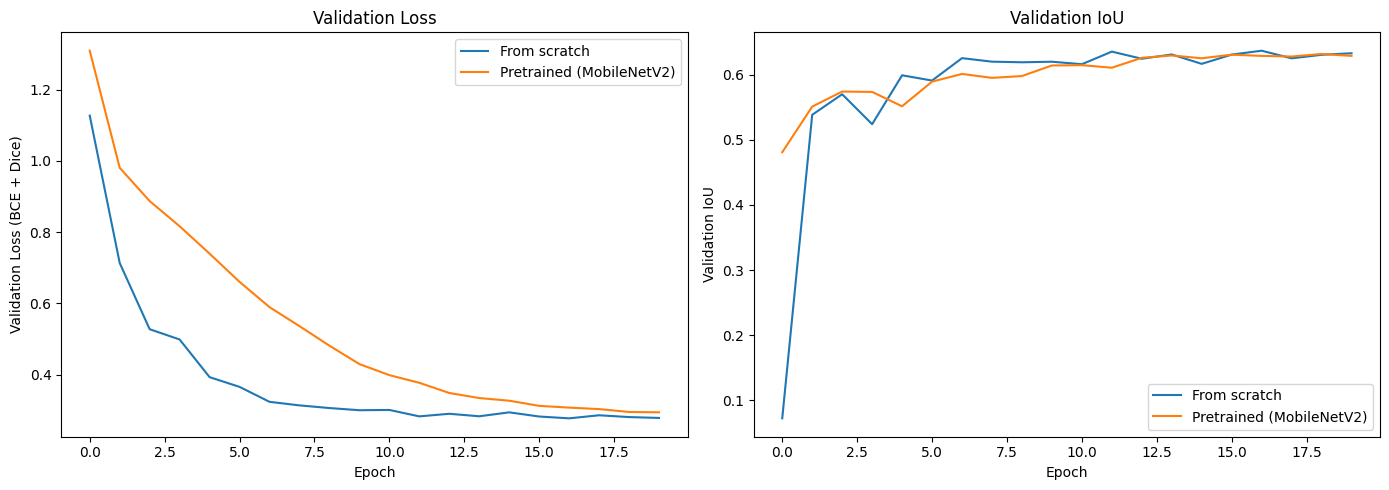

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_scratch.history["val_loss"], label="From scratch")
axes[0].plot(history_pretrained.history["val_loss"], label="Pretrained (MobileNetV2)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation Loss (BCE + Dice)")
axes[0].set_title("Validation Loss")
axes[0].legend()

axes[1].plot(history_scratch.history["val_iou_metric"], label="From scratch")
axes[1].plot(history_pretrained.history["val_iou_metric"], label="Pretrained (MobileNetV2)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation IoU")
axes[1].set_title("Validation IoU")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Model Evaluation

Run a final evaluation pass on the validation set for both models and compare metrics in a
table, then visually inspect a few predicted masks against the ground truth.

In [19]:
results_scratch = model_scratch.evaluate(val_ds, verbose=0, return_dict=True)
results_pretrained = model_pretrained.evaluate(val_ds, verbose=0, return_dict=True)

comparison = pd.DataFrame({
    "Metric": ["Loss (BCE+Dice)", "Dice Coefficient", "IoU", "Binary Accuracy"],
    "From Scratch": [
        results_scratch["loss"],
        results_scratch["dice_coef"],
        results_scratch["iou_metric"],
        results_scratch["binary_accuracy"],
    ],
    "Pretrained (MobileNetV2)": [
        results_pretrained["loss"],
        results_pretrained["dice_coef"],
        results_pretrained["iou_metric"],
        results_pretrained["binary_accuracy"],
    ],
})

comparison


,Metric,From Scratch,Pretrained (MobileNetV2)
0,Loss (BCE+Dice),0.277906,0.295755
1,Dice Coefficient,0.758685,0.742095
2,IoU,0.636756,0.631746
3,Binary Accuracy,0.990885,0.990384


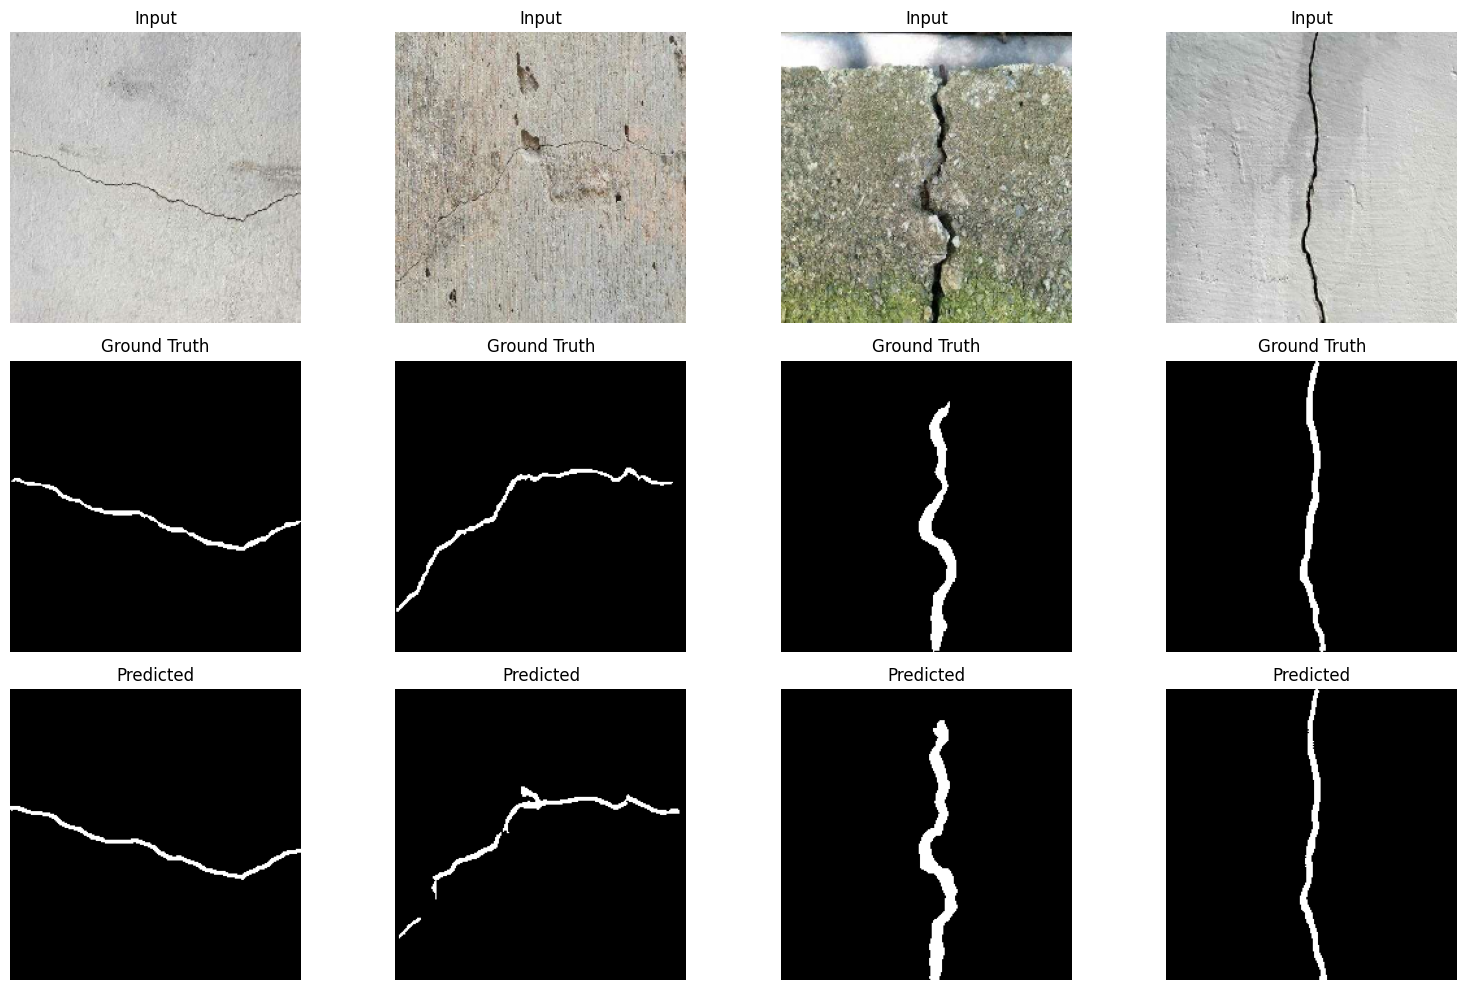

In [20]:
# Qualitative check: image | ground truth mask | predicted mask, for a few validation samples
for imgs, masks in val_ds.take(1):
    preds = model_pretrained.predict(imgs, verbose=0)
    n_show = min(4, imgs.shape[0])

    fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 10))
    for i in range(n_show):
        axes[0, i].imshow(imgs[i])
        axes[0, i].set_title("Input")
        axes[0, i].axis("off")

        axes[1, i].imshow(masks[i, :, :, 0], cmap="gray")
        axes[1, i].set_title("Ground Truth")
        axes[1, i].axis("off")

        axes[2, i].imshow(preds[i, :, :, 0] > 0.5, cmap="gray")
        axes[2, i].set_title("Predicted")
        axes[2, i].axis("off")
    plt.tight_layout()
    plt.show()


## 10. Severity Quantification Pipeline

Same approach as before: a segmentation mask alone doesn't say "how bad" a crack is, so we
convert each predicted mask into two measurements, then bucket the result into a severity
tier.

- **Max crack width** (pixels): the widest point along the crack, measured via
  skeletonization + distance transform.
- **Area coverage** (%): what fraction of the image is crack.

### Why pixels, not millimeters
Converting pixel-width into real-world millimeters needs a camera calibration step (known
distance/field of view) that this dataset doesn't provide. Rather than invent a calibration
assumption, severity here is reported **relative to this dataset's own distribution**
(percentile-based cutoffs). See Section 13 for how to extend this to true millimeter
measurements against a named standard (e.g. AASHTO's ~1.6mm / ~3.2mm crack-width
thresholds) if calibrated images become available.

In [21]:
def compute_crack_width_profile(mask):
    """
    Given a binary crack mask (2D numpy array, 1 = crack, 0 = background), returns an
    array of estimated crack widths (pixels) sampled along the crack's skeleton, plus the
    skeleton itself.
    """
    mask_bool = mask.astype(bool)
    if mask_bool.sum() == 0:
        return np.array([]), mask_bool

    skeleton = skeletonize(mask_bool)
    distance = ndimage.distance_transform_edt(mask_bool)  # distance to nearest background pixel
    widths_at_skeleton = distance[skeleton] * 2            # *2: half-width -> full width
    return widths_at_skeleton, skeleton


def crack_metrics(mask):
    """Summary metrics used for severity bucketing."""
    widths, skeleton = compute_crack_width_profile(mask)
    area_pct = (mask.sum() / mask.size) * 100
    return {
        "max_width_px": float(widths.max()) if len(widths) else 0.0,
        "mean_width_px": float(widths.mean()) if len(widths) else 0.0,
        "area_pct": float(area_pct),
        "skeleton": skeleton,
    }


In [22]:
# --- Calibrate severity tiers against the validation set ---
# Run the pretrained model over all validation images, collect crack-width metrics for
# every detected crack, and use the 33rd/66th percentiles as minor/moderate/severe cutoffs.
# This makes the tiers dataset-relative instead of arbitrary numbers pulled from nowhere.

all_metrics = []

for imgs, masks in val_ds:
    preds = model_pretrained.predict(imgs, verbose=0)
    for i in range(preds.shape[0]):
        binary_mask = (preds[i, :, :, 0] > 0.5).astype(np.uint8)
        if binary_mask.sum() == 0:
            continue
        m = crack_metrics(binary_mask)
        all_metrics.append({"max_width_px": m["max_width_px"], "area_pct": m["area_pct"]})

metrics_df = pd.DataFrame(all_metrics)
print(f"Collected crack metrics for {len(metrics_df)} validation images with detected cracks.")

WIDTH_MINOR_MODERATE_CUTOFF = metrics_df["max_width_px"].quantile(0.33)
WIDTH_MODERATE_SEVERE_CUTOFF = metrics_df["max_width_px"].quantile(0.66)

print(f"Minor/Moderate cutoff:  {WIDTH_MINOR_MODERATE_CUTOFF:.2f} px")
print(f"Moderate/Severe cutoff: {WIDTH_MODERATE_SEVERE_CUTOFF:.2f} px")

metrics_df.describe()


Collected crack metrics for 200 validation images with detected cracks.
Minor/Moderate cutoff:  5.66 px
Moderate/Severe cutoff: 7.21 px


,max_width_px,area_pct
count,200.000000,200.000000
mean,6.984974,2.234963
std,2.736343,1.008600
min,4.000000,0.695552
25%,4.472136,1.622290
50%,6.000000,1.929209
75%,8.246211,2.510164
max,20.880613,8.225048


In [23]:
def bucket_severity(max_width_px):
    """
    Map a max crack width (pixels) to a severity tier, using cutoffs derived from this
    dataset's own distribution (previous cell). These tiers are RELATIVE to this
    dataset/camera setup, not absolute millimeter thresholds -- see the markdown note
    above and Section 13 for how to extend this to calibrated real-world measurements.
    """
    if max_width_px == 0:
        return "No Crack"
    elif max_width_px < WIDTH_MINOR_MODERATE_CUTOFF:
        return "Minor"
    elif max_width_px < WIDTH_MODERATE_SEVERE_CUTOFF:
        return "Moderate"
    else:
        return "Severe"


metrics_df["severity"] = metrics_df["max_width_px"].apply(bucket_severity)
metrics_df["severity"].value_counts()


,count
severity,
Severe,78
Moderate,70
Minor,52


## 11. End-to-End Demo

Ties everything together: given a raw image, run segmentation, measure the crack, assign a
severity tier, and display the result the way an inspector would want to see it.

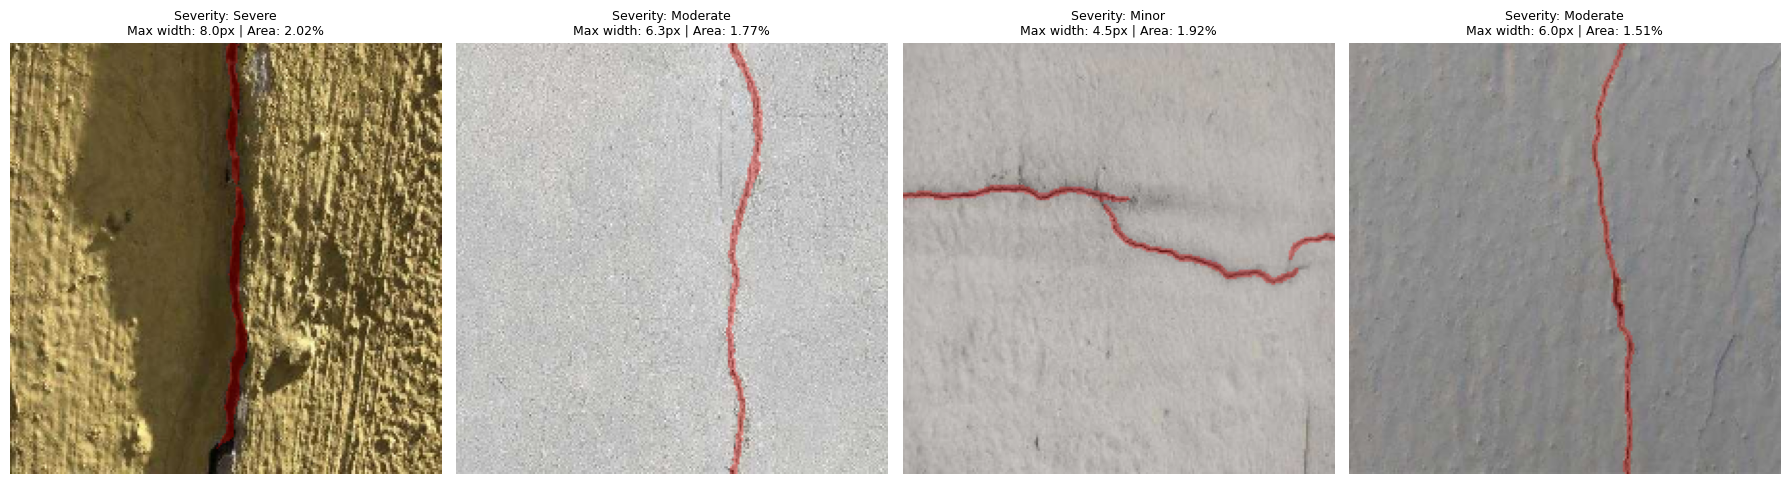

In [24]:
def analyze_crack_image(image_path, model, img_size):
    """
    Full pipeline for one image:
      1. Load & resize the image to the model's expected input size.
      2. Run the U-Net to get a predicted crack mask.
      3. Measure crack width/area from the mask.
      4. Bucket into a severity tier.
    """
    img_raw = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_raw, (img_size, img_size))
    img_input = np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=0)

    pred = model.predict(img_input, verbose=0)[0, :, :, 0]
    binary_mask = (pred > 0.5).astype(np.uint8)

    metrics = crack_metrics(binary_mask)
    severity = bucket_severity(metrics["max_width_px"])

    return {"image": img_resized, "mask": binary_mask, "severity": severity, "metrics": metrics}


def plot_analysis(analysis, ax):
    img = analysis["image"].copy()
    if analysis["mask"].sum() > 0:
        overlay = img.copy()
        overlay[analysis["mask"] > 0] = [255, 0, 0]
        img = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

    ax.imshow(img)
    title = (f"Severity: {analysis['severity']}\n"
              f"Max width: {analysis['metrics']['max_width_px']:.1f}px | "
              f"Area: {analysis['metrics']['area_pct']:.2f}%")
    ax.set_title(title, fontsize=9)
    ax.axis("off")


demo_samples = random.sample(val_images, min(4, len(val_images)))
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, img_path in zip(axes, demo_samples):
    analysis = analyze_crack_image(img_path, model_pretrained, CONFIG["img_size"])
    plot_analysis(analysis, ax)
plt.tight_layout()
plt.show()


## 12. Save & Export

Save both trained models in the native Keras format. Colab's runtime storage is wiped when
the session ends, so copy these to Google Drive if you want them to persist.

In [25]:
model_scratch.save("unet_scratch.keras")
model_pretrained.save("unet_mobilenetv2.keras")

print("Saved unet_scratch.keras and unet_mobilenetv2.keras")


Saved unet_scratch.keras and unet_mobilenetv2.keras


Choose one or more images to test (JPG or PNG).


Saving crack1.jpeg to crack1 (1).jpeg


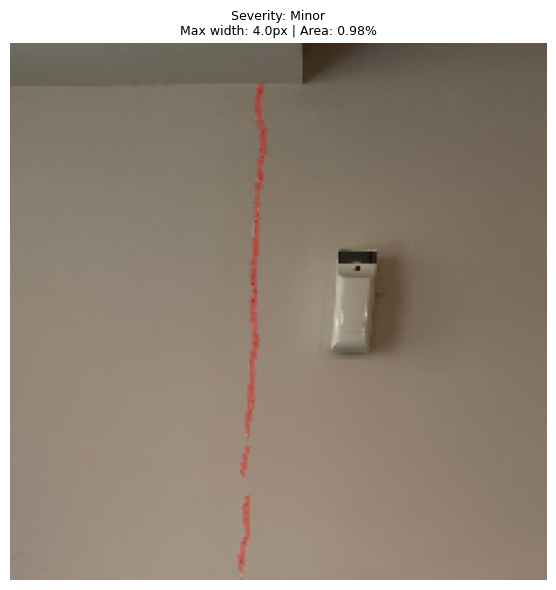

In [27]:
# ---------------------------------------------------------------------------
# Test With Your Own Photo
# ---------------------------------------------------------------------------
from google.colab import files

print("Choose one or more images to test (JPG or PNG).")
uploaded = files.upload()

if not uploaded:
    print("No files uploaded.")
else:
    filenames = list(uploaded.keys())
    fig, axes = plt.subplots(1, len(filenames), figsize=(6 * len(filenames), 6))
    if len(filenames) == 1:
        axes = [axes]  # keep indexing consistent whether there's 1 image or several

    for ax, filename in zip(axes, filenames):
        analysis = analyze_crack_image(filename, model_pretrained, CONFIG["img_size"])
        plot_analysis(analysis, ax)

    plt.tight_layout()
    plt.show()

In [ ]:
# OPTIONAL: mount Google Drive and copy weights there so they survive
# past the end of this Colab session. Uncomment to use.

# from google.colab import drive
# drive.mount('/content/drive')
#
# import shutil
# drive_folder = "/content/drive/MyDrive/crack_segmentation_project"
# os.makedirs(drive_folder, exist_ok=True)
# shutil.copy("unet_scratch.keras", drive_folder)
# shutil.copy("unet_mobilenetv2.keras", drive_folder)
# print(f"Models copied to {drive_folder}")


## 13. Summary & Next Steps

**What was built:**
- A TensorFlow/Keras U-Net segmentation pipeline, trained two ways (random-weight encoder
  vs. ImageNet-pretrained MobileNetV2 encoder) on the Crack Segmentation dataset
  (3,717 training / 200 validation images), with a matching decoder shared between both.
- A BCE+Dice loss and IoU/Dice evaluation, chosen specifically to handle the severe
  foreground/background imbalance of thin crack regions.
- A geometric post-processing step (skeletonization + distance transform) converting raw
  masks into crack-width and area-coverage measurements.
- A relative (dataset-percentile-based) severity classifier: Minor / Moderate / Severe.
- An end-to-end demo: image in, severity-labeled visualization out.

**Results, final epoch (20/20):**

| Metric | From Scratch | Pretrained (MobileNetV2) |
|---|---|---|
| Loss (BCE + Dice) | 0.278 | 0.296 |
| Dice Coefficient | 0.759 | 0.742 |
| IoU | 0.637 | 0.632 |
| Binary Accuracy | 0.9909 | 0.9904 |

Contrary to the initial hypothesis, the from-scratch model matched or marginally
outperformed the pretrained model on every metric. The training curves explain why: the
pretrained encoder started with a large, genuine head start (val IoU ~0.48 at epoch 0 vs.
~0.07 for the from-scratch model), but the from-scratch model overtook it within the first
two epochs and held a small, consistent lead from there to epoch 20. The most likely
cause: the pretrained encoder was left fully trainable and fine-tuned jointly with a
randomly-initialized decoder from the first step, so the decoder's early noisy gradients
likely disturbed the pretrained features before the decoder had stabilized enough to use
them well, a known risk when skipping a staged freeze-then-unfreeze fine-tuning schedule.
This is a fixable methodological choice, not evidence that transfer learning doesn't help
here.

**Severity calibration**, on 200 validation images (all crack-positive): Minor/Moderate
cutoff at 5.66px max width, Moderate/Severe cutoff at 7.21px. Resulting distribution: 78
Severe, 70 Moderate, 52 Minor.

**Generalization test:** an independently captured photograph of a real wall crack was
missed entirely in its original wide, full-room framing (0.0px width detected), but
correctly detected and classified as Minor once cropped tightly. Most likely cause:
resizing a wide photo down to the model's 224x224 input reduces a hairline crack to a
sub-pixel width before the model ever sees it. This points to a capture-distance
limitation, not a failure to recognize crack morphology in general.

**Honest limitations:**
- Both models were capped at 20 epochs by available compute time, not by convergence;
  validation curves appear to be flattening but early stopping was never formally
  triggered.
- Each configuration was trained once, so the from-scratch model's edge over the
  pretrained one cannot be statistically distinguished from run-to-run variance with the
  data currently available.
- All 200 validation images contained a labelled crack, so false-positive rate on
  genuinely crack-free surfaces was not measured.
- Severity tiers are relative to this dataset/camera setup, not calibrated to a physical
  millimetre standard.
- Single crack class only, and one combined mask per image rather than separating
  individual, distinct cracks.

**Stretch goals / future work:**
- Re-run the transfer-learning arm with a staged schedule (freeze the pretrained encoder
  while the decoder trains for several epochs, then unfreeze at a reduced learning rate)
  to test whether that recovers the expected transfer-learning advantage.
- Calibrate pixel-to-mm conversion (e.g. fixed camera distance, or a reference object of
  known size in frame) against a named standard (e.g. AASHTO's ~1.6mm / ~3.2mm crack width
  thresholds).
- Tile wide photographs into closer-range sections before inference, to address the
  capture-distance failure mode found in the generalization test.
- Deploy as a lightweight demo app (e.g. Streamlit) for uploading a photo and getting an
  instant severity read, similar in spirit to the PPE-compliance project.
